# DS 4400 Final Project
Step 1 Notebook - Cleaning the data

## Importing the dataset from kaggle

In [10]:
%pip install kagglehub
%pip install pandas
%pip install numpy
%pip install matplotlib.pyplot
%pip install seaborn 


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[no

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alexteboul/heart-disease-health-indicators-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/thillainayakisudhakar/.cache/kagglehub/datasets/alexteboul/heart-disease-health-indicators-dataset/versions/3


## Step 1: Data Loading

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path from kagglehub download
DATA_PATH = path + "/heart_disease_health_indicators_BRFSS2015.csv"

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Shape: (253680, 22)

Column names:
['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [13]:
# First look at the data
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [14]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [15]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found.")

Missing values per column:
No missing values found.


In [16]:
# Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.2f}%)")
df = df.drop_duplicates()
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows: 23899 (9.42%)
Shape after dropping duplicates: (229781, 22)


## Step 2: Exploratory Data Analysis (EDA)

In [17]:
# Summary statistics for all features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HeartDiseaseorAttack,229781.0,0.103216,0.304241,0.0,0.0,0.0,0.0,1.0
HighBP,229781.0,0.454441,0.497921,0.0,0.0,0.0,1.0,1.0
HighChol,229781.0,0.441760,0.496598,0.0,0.0,0.0,1.0,1.0
CholCheck,229781.0,0.959535,0.197047,0.0,1.0,1.0,1.0,1.0
BMI,229781.0,28.685670,6.786360,12.0,24.0,27.0,32.0,98.0
Smoker,229781.0,0.465661,0.498821,0.0,0.0,0.0,1.0,1.0
Stroke,229781.0,0.044756,0.206767,0.0,0.0,0.0,0.0,1.0
Diabetes,229781.0,0.325627,0.724623,0.0,0.0,0.0,0.0,2.0
PhysActivity,229781.0,0.733355,0.442206,0.0,0.0,1.0,1.0,1.0
Fruits,229781.0,0.612966,0.487073,0.0,0.0,1.0,1.0,1.0


### 2a. Feature type breakdown

The dataset has two types of features:
- **Binary (0/1)**: HighBP, HighChol, CholCheck, Smoker, Stroke, Diabetes, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, DiffWalk, Sex, HeartDiseaseorAttack
- **Ordinal/Continuous**: BMI, GenHlth (1–5), MentHlth (0–30 days), PhysHlth (0–30 days), Age (1–13 bracket), Education (1–6), Income (1–8)

In [18]:
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes',
    'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
    'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex'
]

continuous_features = ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

TARGET = 'HeartDiseaseorAttack'

### 2b. Distribution of continuous features

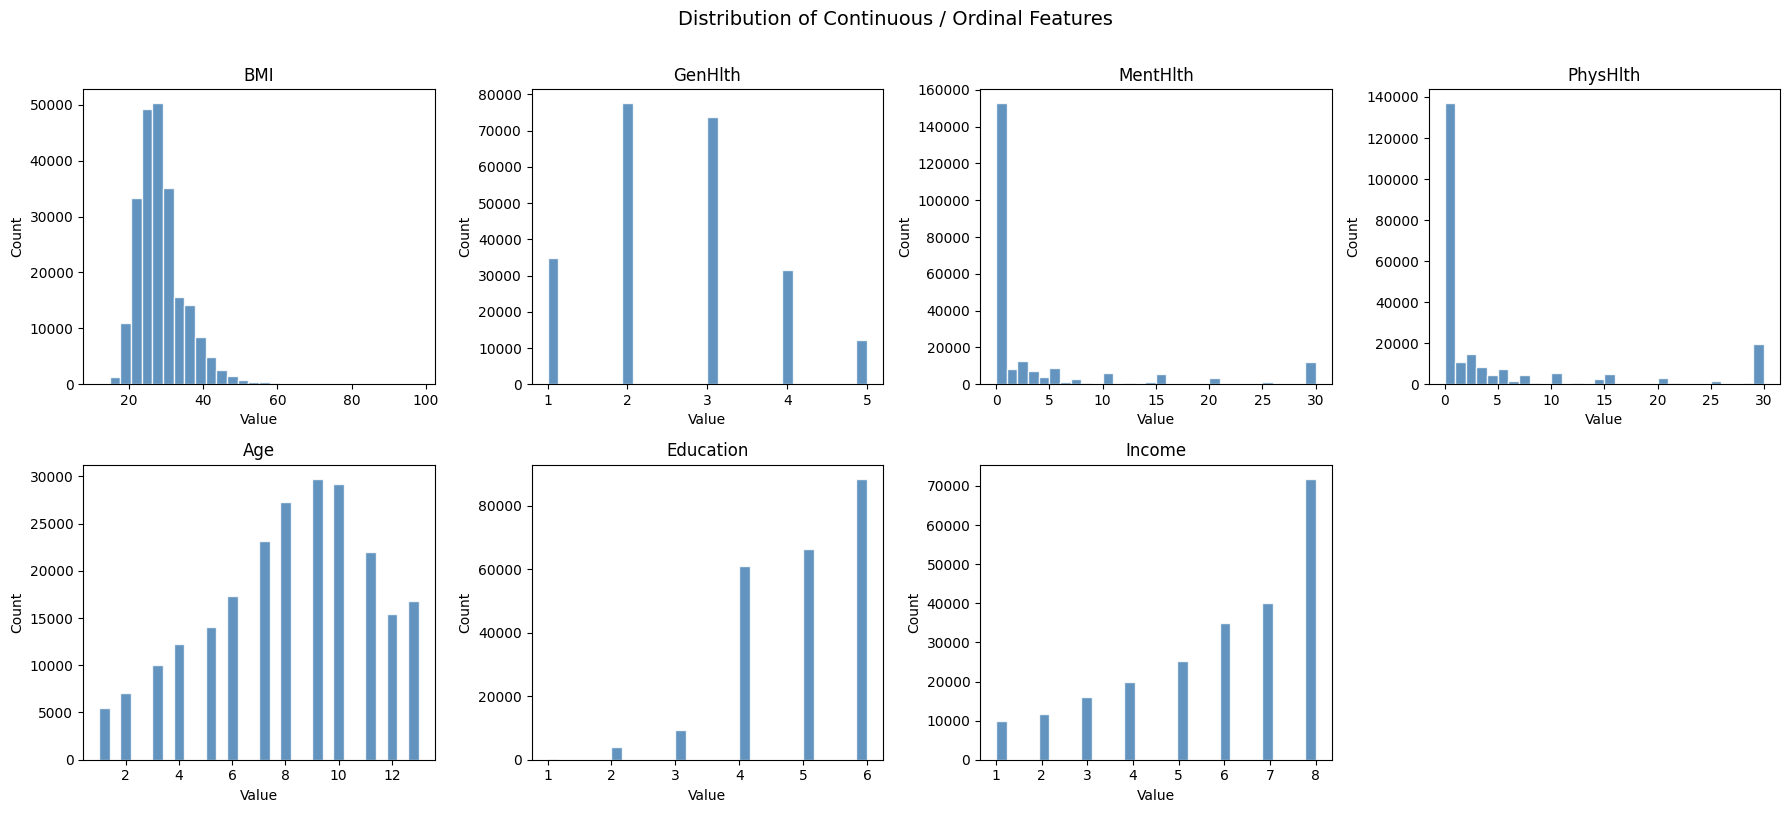

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle('Distribution of Continuous / Ordinal Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2c. Prevalence of binary features

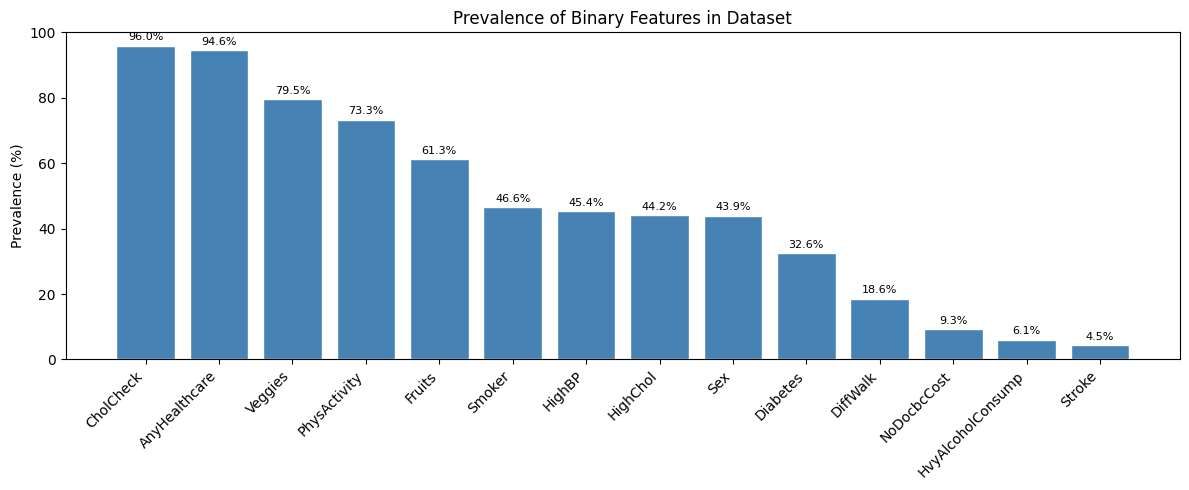

In [20]:
prevalence = df[binary_features].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(prevalence.index, prevalence.values * 100, color='steelblue', edgecolor='white')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Prevalence (%)')
plt.title('Prevalence of Binary Features in Dataset')
plt.ylim(0, 100)

for bar, val in zip(bars, prevalence.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### 2d. Correlation heatmap

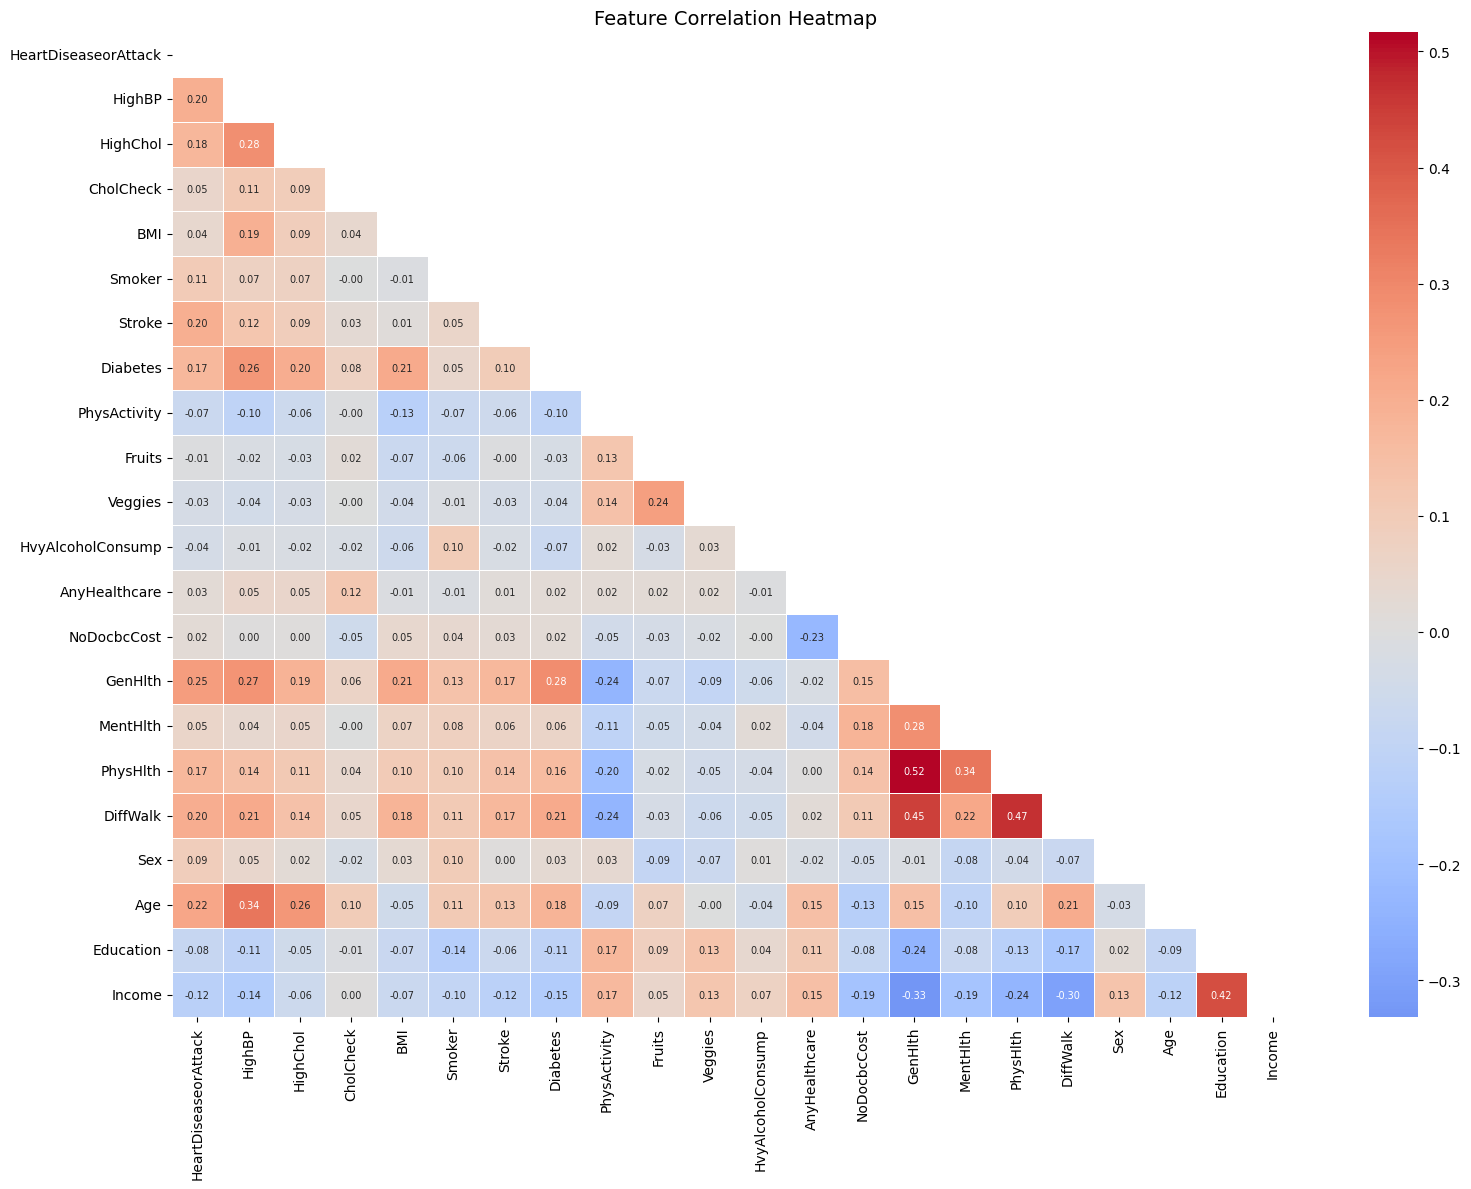

In [21]:
plt.figure(figsize=(16, 12))
corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, annot_kws={'size': 7}
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

### 2e. Feature correlations with target (HeartDiseaseorAttack)

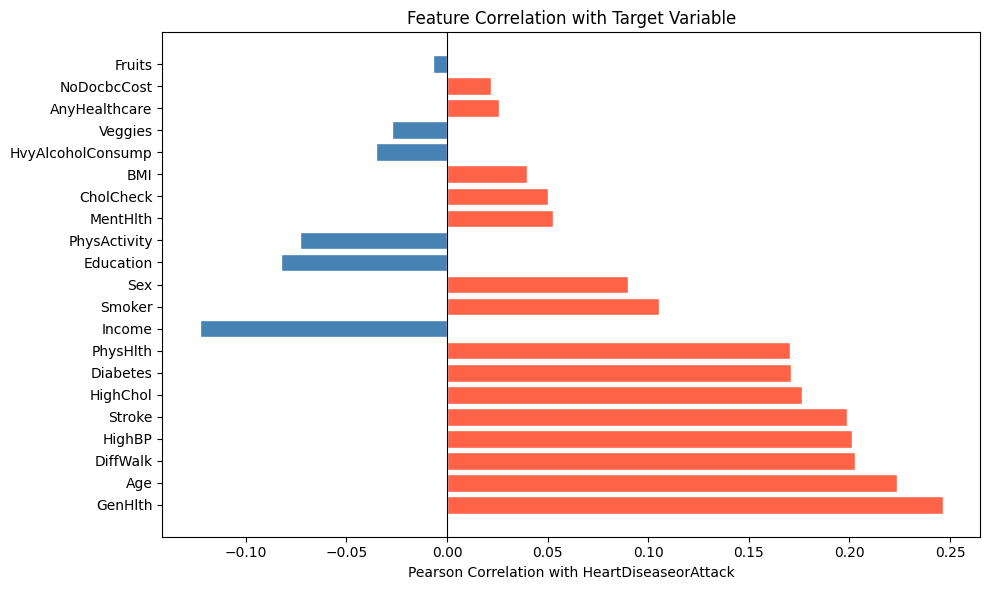


Top 5 positively correlated features:
GenHlth     0.246411
Age         0.223626
DiffWalk    0.202779
HighBP      0.201271
Stroke      0.198863
Name: HeartDiseaseorAttack, dtype: float64

Top 5 negatively correlated features:
Income              -0.122908
Education           -0.082466
PhysActivity        -0.073267
HvyAlcoholConsump   -0.035453
Veggies             -0.027330
Name: HeartDiseaseorAttack, dtype: float64


In [22]:
target_corr = df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with HeartDiseaseorAttack')
plt.title('Feature Correlation with Target Variable')
plt.tight_layout()
plt.show()

print("\nTop 5 positively correlated features:")
print(target_corr[target_corr > 0].head())
print("\nTop 5 negatively correlated features:")
print(target_corr[target_corr < 0].head())

## Step 3: Class Imbalance Analysis

In [23]:
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100

print("Class distribution:")
print(f"  No Heart Disease (0): {counts[0]:,}  ({pct[0]:.2f}%)")
print(f"  Heart Disease    (1): {counts[1]:,}  ({pct[1]:.2f}%)")
print(f"\nImbalance ratio (majority:minority): {counts[0]/counts[1]:.1f}:1")

Class distribution:
  No Heart Disease (0): 206,064  (89.68%)
  Heart Disease    (1): 23,717  (10.32%)

Imbalance ratio (majority:minority): 8.7:1


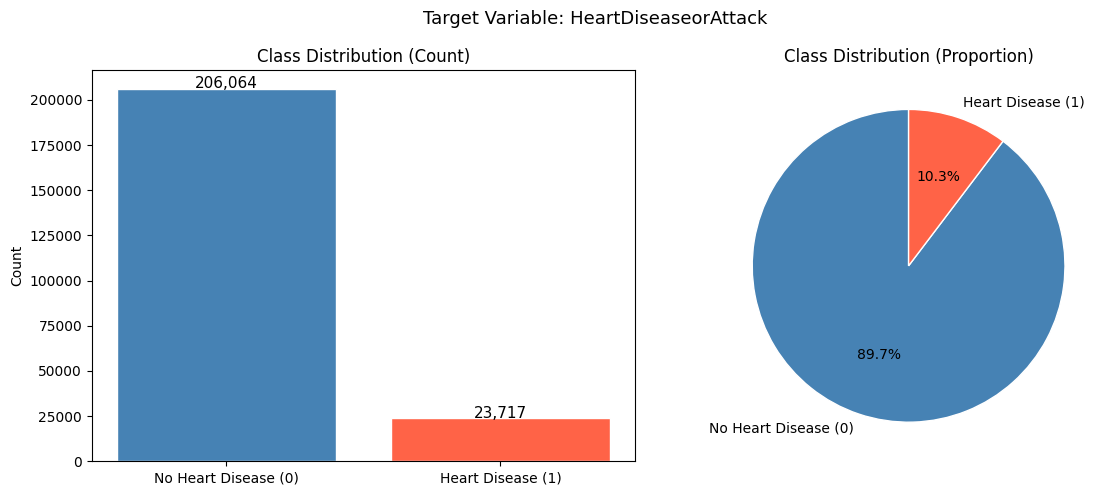

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['No Heart Disease (0)', 'Heart Disease (1)'],
            counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Count)')
for i, (bar, val) in enumerate(zip(axes[0].patches, counts.values)):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=['No Heart Disease (0)', 'Heart Disease (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Distribution (Proportion)')

plt.suptitle('Target Variable: HeartDiseaseorAttack', fontsize=13)
plt.tight_layout()
plt.show()

### 3a. Risk factor rates by class

How much more common are key risk factors among patients with heart disease vs without?

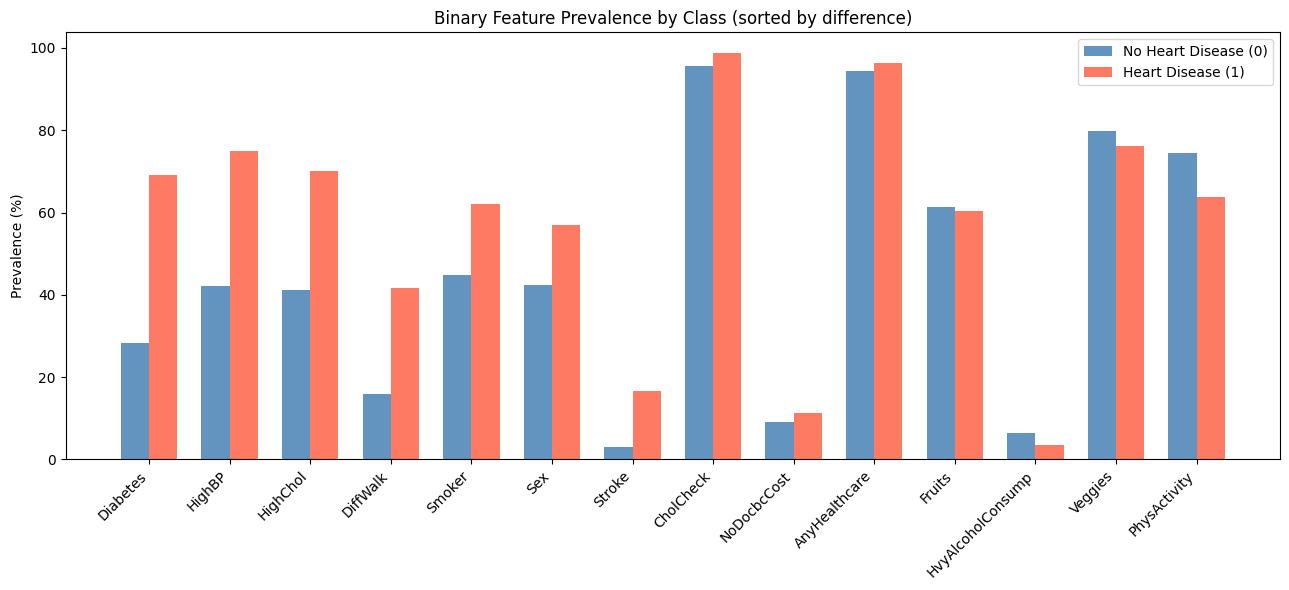


Prevalence gap (Heart Disease % - No Heart Disease %):
Diabetes             40.7
HighBP               32.9
HighChol             28.8
DiffWalk             25.9
Smoker               17.2
Sex                  14.6
Stroke               13.5
CholCheck             3.2
NoDocbcCost           2.1
AnyHealthcare         1.9
Fruits               -1.1
HvyAlcoholConsump    -2.8
Veggies              -3.6
PhysActivity        -10.6


In [25]:
# Compare binary feature rates between classes
risk_comparison = df.groupby(TARGET)[binary_features].mean() * 100

# Sort by difference (heart disease rate - no heart disease rate)
diff = (risk_comparison.loc[1] - risk_comparison.loc[0]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(diff))
width = 0.35

bars0 = ax.bar(x - width/2, risk_comparison.loc[0][diff.index], width,
               label='No Heart Disease (0)', color='steelblue', alpha=0.85)
bars1 = ax.bar(x + width/2, risk_comparison.loc[1][diff.index], width,
               label='Heart Disease (1)', color='tomato', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(diff.index, rotation=45, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Binary Feature Prevalence by Class (sorted by difference)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nPrevalence gap (Heart Disease % - No Heart Disease %):")
print(diff.round(1).to_string())

### 3b. Continuous feature distributions by class

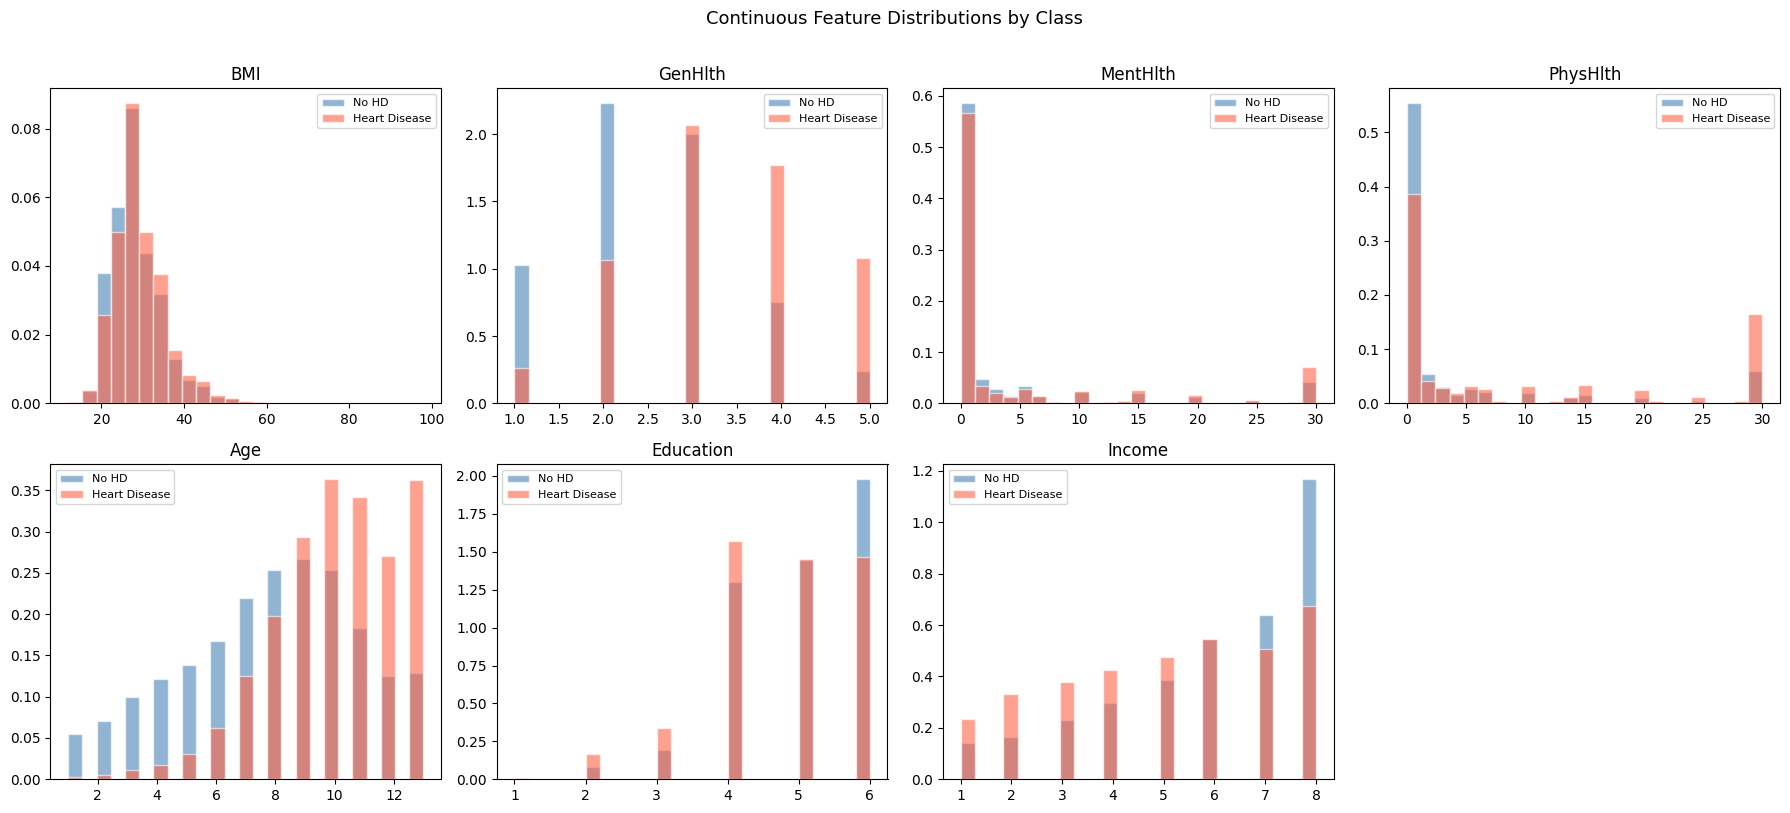

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    for cls, color, label in [(0, 'steelblue', 'No HD'), (1, 'tomato', 'Heart Disease')]:
        axes[i].hist(df[df[TARGET] == cls][col], bins=25, alpha=0.6,
                     color=color, label=label, density=True, edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Continuous Feature Distributions by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3c. Summary

**Key takeaways:**
- The dataset is heavily imbalanced — only ~9% of records are positive (heart disease). Raw accuracy would be misleading (~91% by always predicting 0), justifying our use of AUC-ROC and F1 as primary metrics.
- SMOTE will be applied to the training set only (after the train/val/test split) to avoid data leakage.
- The strongest positive predictors of heart disease appear to be HighBP, HighChol, Stroke, DiffWalk, and Age.
- PhysActivity, Income, and Education show a negative correlation — patients with lower income/education and less physical activity are at higher risk.

In [27]:
# Save cleaned dataset for use in other notebooks
CLEANED_PATH = "heart_disease_cleaned.csv"
df.to_csv(CLEANED_PATH, index=False)
print(f"Saved cleaned dataset to: {CLEANED_PATH}  ({df.shape[0]:,} rows, {df.shape[1]} cols)")

Saved cleaned dataset to: heart_disease_cleaned.csv  (229,781 rows, 22 cols)
